1. Import Libraries

In [1]:
# Data handling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
from sklearn.datasets import load_iris

# ML utilities
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Tree visualization
from sklearn import tree

2. Load Dataset

In [2]:
# Load dataset
iris = load_iris()

# Create DataFrame
df = pd.DataFrame(
    iris.data,
    columns=['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
)

# Add target column
df['Species'] = iris.target

# Preview
print(df.head())

   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  Species
0            5.1           3.5            1.4           0.2        0
1            4.9           3.0            1.4           0.2        0
2            4.7           3.2            1.3           0.2        0
3            4.6           3.1            1.5           0.2        0
4            5.0           3.6            1.4           0.2        0


3. Feature Engineering

In [3]:
# Creating additional features (improves model learning)
df['Sepal_Petal_Length_Diff'] = df['SepalLengthCm'] - df['PetalLengthCm']
df['Sepal_Petal_Width_Diff'] = df['SepalWidthCm'] - df['PetalWidthCm']

4. Visualization

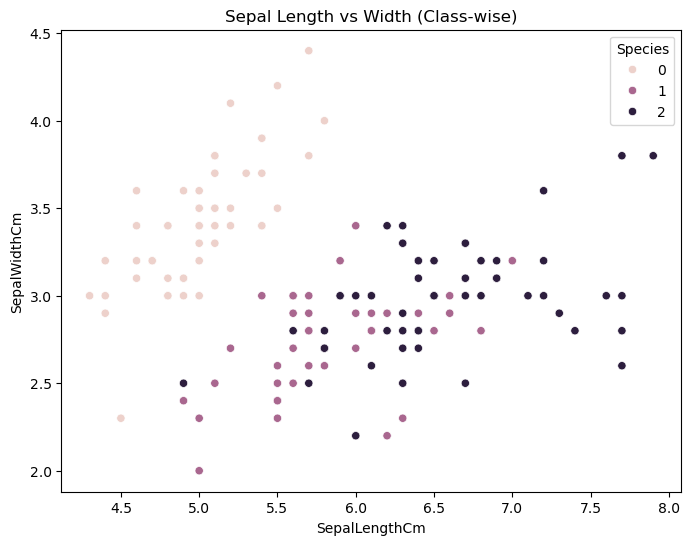

In [4]:
# Better visualization with class separation
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='SepalLengthCm',
    y='SepalWidthCm',
    hue='Species'
)

plt.title("Sepal Length vs Width (Class-wise)")
plt.show()

5. Feature Selection

In [5]:
# Features
X = df[
    [
        'SepalLengthCm',
        'SepalWidthCm',
        'PetalLengthCm',
        'PetalWidthCm',
        'Sepal_Petal_Length_Diff',
        'Sepal_Petal_Width_Diff'
    ]
]

# Target
y = df['Species']

6. Train-Test Split

In [6]:
# Simpler and cleaner split (removed unnecessary triple split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

7. Model Training

In [7]:
# Initialize model
model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4   # added to prevent overfitting
)

# Train model
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


8. Cross-Validation

In [8]:
# Evaluate model stability
cv_score = cross_val_score(model, X_train, y_train, cv=5).mean()

print("Cross-validation Accuracy:", cv_score)

Cross-validation Accuracy: 0.9142857142857143


9. Predictions & Evaluation

In [9]:
# Predictions
y_pred = model.predict(X_test)

# Accuracy
print("Test Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.9555555555555556

Confusion Matrix:
[[19  0  0]
 [ 0 12  1]
 [ 0  1 12]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.92      0.92      0.92        13
           2       0.92      0.92      0.92        13

    accuracy                           0.96        45
   macro avg       0.95      0.95      0.95        45
weighted avg       0.96      0.96      0.96        45



10. Tree Visualization

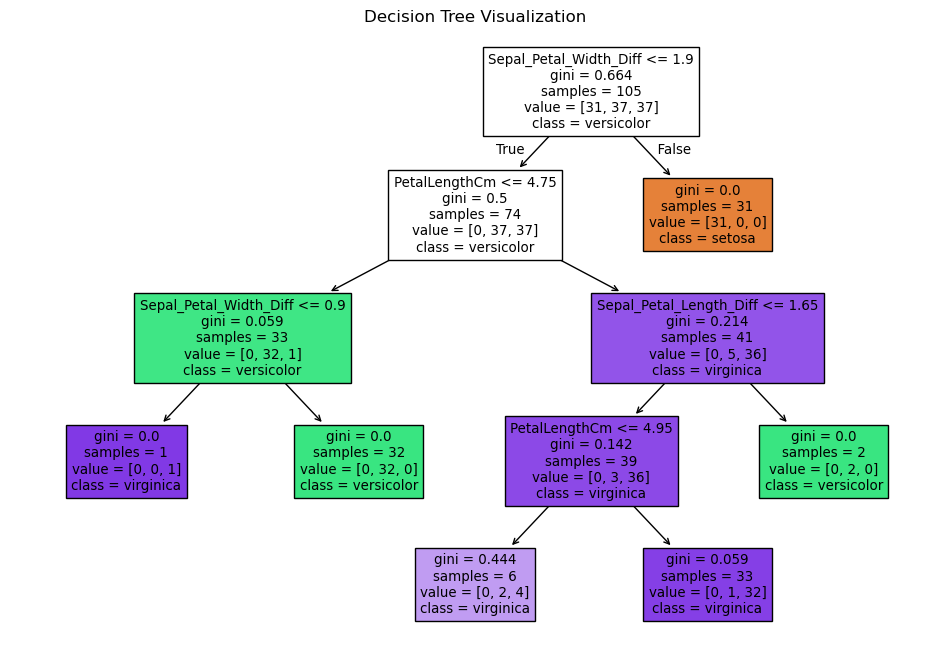

In [10]:
# Plot decision tree
plt.figure(figsize=(12,8))

tree.plot_tree(
    model,
    filled=True,
    feature_names=X.columns,
    class_names=iris.target_names
)

plt.title("Decision Tree Visualization")
plt.show()

In [ ]:
11. Feature Importance (NEW – very important)

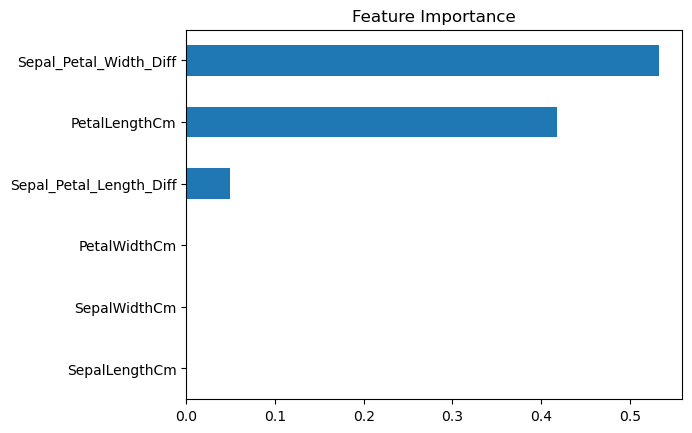

In [12]:
# Show which features matter most
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')

plt.title("Feature Importance")
plt.show()